# Internações × Qualidade do Ar — Rio de Janeiro

**Objetivo:** consolidar e sincronizar séries temporais diárias de qualidade do ar (estações QUALIAR/DataRio) com registros de internações por doenças respiratórias (DATASUS) para análise exploratória e modelagem preditiva.

**Escopo:**
- Agregar séries diárias de poluentes e variáveis meteorológicas às contagens diárias de internações respiratórias;
- Gerar features temporais (lags, médias móveis, componentes STL), indicadores de calendário e avaliar impacto de poluentes nas internações;
- Estimar modelos preditivos (Random Forest, HistGradientBoosting, LSTM) e calcular intervalos de incerteza (conformal pairs).

**Doenças respiratórias (códigos CID-10) consideradas:**
- J15, J18 — Pneumonia
- J21 — Bronquiolite
- J96 — Insuficiência respiratória
- J40, J41, J42 — Bronquite
- J43, J44 — DPOC / Enfisema
- J45, J46 — Asma

**Fontes de dados:**
- QUALIAR / DataRio: séries temporais de poluentes e variáveis ambientais (PM2.5, PM10, O3, NO2, CO, SO2, etc.);
- DATASUS: internações diárias por CID-10 (agregadas por data).

**Estrutura do notebook:**
1. Configurações e importações;
2. Unificação dos datasets (internações × ambiente);
3. Engenharia de features temporais (lags, médias móveis, janelas causais);
4. Modelagem: RF (com TTR) e LSTM
5. Avaliação, intervalos conformais e interpretação (SHAP).

(Use as células seguintes para ajustar parâmetros, filtrar períodos e executar pipelines de treino/avaliação.)

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
from pathlib import Path

from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import TransformedTargetRegressor
from sklearn.base import clone

from typing import Tuple, List

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Unificação dos datasets (Internações × Ambiente)

**Objetivo:** juntar a série diária de **internações respiratórias** ao dataset diário de **variáveis ambientais** do Rio de Janeiro.

In [2]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/INTER_DR_RJ_SEAZONALITY.csv"
url_qualiar     = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/DataRio/QUALIAR_RIO_DE_JANEIRO_TRATADO.csv"

df_internacoes = pd.read_csv(url_internacoes, encoding="utf-8")
df_qualiar     = pd.read_csv(url_qualiar,     encoding="utf-8")

df_unificado = (
    pd.merge(df_qualiar, df_internacoes, on="data_dia", how="inner")
      .sort_values("data_dia")
      .reset_index(drop=True)
)

df_unificado.drop(columns=["ano", "mes", "dia"], inplace=True, errors="ignore")

print("Dimensões do unificado:", df_unificado.shape)
print("Intervalo de datas:", df_unificado["data_dia"].min(), "→", df_unificado["data_dia"].max())
print("\nColunas:", df_unificado.columns.tolist())
print("\nAmostra:")
display(df_unificado.head())
print("\nTipos de dados:")
print(df_unificado.dtypes)


Dimensões do unificado: (4748, 40)
Intervalo de datas: 2012-01-01 → 2024-12-30

Colunas: ['data_dia', 'chuva', 'temp', 'ur', 'co', 'no', 'no2', 'nox', 'so2', 'o3', 'pm10', 'pm2_5', 'temp_min', 'temp_max', 'AQI', 'Qualidade_do_Ar', 'y', 'year', 'month', 'dow', 'doy', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_lag_7', 'roll7_mean', 'roll7_std', 'roll14_mean', 'roll14_std', 'roll30_mean', 'roll30_std', 'stl_trend', 'stl_season']

Amostra:


,data_dia,chuva,temp,ur,co,no,no2,nox,so2,o3,...,y_lag_3,y_lag_7,roll7_mean,roll7_std,roll14_mean,roll14_std,roll30_mean,roll30_std,stl_trend,stl_season
0,2012-01-01,0.849992,25.835,92.165,0.215703,1.256189,4.184802,2.770516,1.567692,6.469835,...,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,645.896962,-197.197248
1,2012-01-02,0.891094,22.836,95.589,0.181572,1.884591,4.419030,3.019050,1.189413,6.013862,...,NaN,NaN,507.000000,0.000000,507.000000,0.000000,507.000000,0.000000,645.554593,-34.355772
2,2012-01-03,0.024357,24.948,76.139,0.165267,2.021231,4.512331,3.108324,2.004412,5.246714,...,NaN,NaN,617.500000,156.270599,617.500000,156.270599,617.500000,156.270599,645.212035,-71.854513
3,2012-01-04,0.047493,26.006,72.904,0.170964,2.175012,5.096621,3.324094,1.736737,6.754888,...,507.0,NaN,554.666667,155.094595,554.666667,155.094595,554.666667,155.094595,644.869285,-144.550309
4,2012-01-05,-0.000000,26.498,75.514,0.169471,2.007440,4.843477,3.181217,1.715770,7.889395,...,728.0,NaN,520.000000,144.372204,520.000000,144.372204,520.000000,144.372204,644.526341,-173.562390



Tipos de dados:
data_dia            object
chuva              float64
temp               float64
ur                 float64
co                 float64
no                 float64
no2                float64
nox                float64
so2                float64
o3                 float64
pm10               float64
pm2_5              float64
temp_min           float64
temp_max           float64
AQI                float64
Qualidade_do_Ar    float64
y                    int64
year                 int64
month                int64
dow                  int64
doy                  int64
is_weekend           int64
dow_sin            float64
dow_cos            float64
month_sin          float64
month_cos          float64
doy_sin            float64
doy_cos            float64
y_lag_1            float64
y_lag_2            float64
y_lag_3            float64
y_lag_7            float64
roll7_mean         float64
roll7_std          float64
roll14_mean        float64
roll14_std         float64
roll30_mean

In [3]:
project_root = Path().resolve().parents[1]  
output_dir = project_root / "data" 
output_dir.mkdir(parents=True, exist_ok=True)

output_csv_path = output_dir / "INTERNACOES_x_QUALIAR_NEW.csv"
df_unificado.to_csv(output_csv_path, index=False, encoding="utf-8")

#### Série temporal das internações

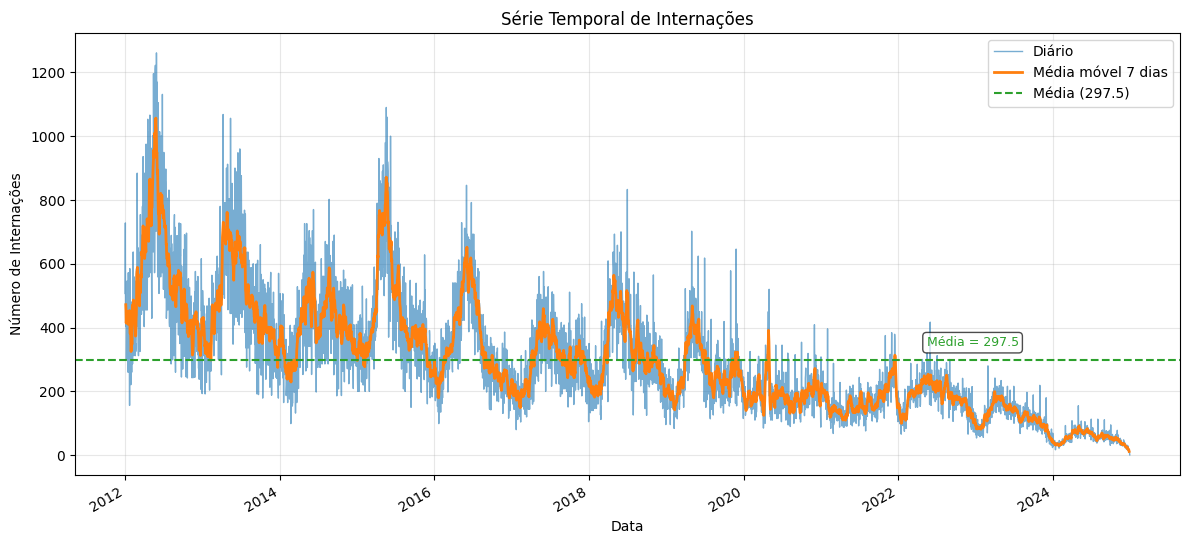

In [4]:
ts = df_unificado.set_index(pd.to_datetime(df_unificado['data_dia']))['y']

plt.figure(figsize=(12, 6))
plt.plot(ts.index, ts.values, label='Diário', color='C0', alpha=0.6, linewidth=1)
plt.plot(ts.index, ts.rolling(7, center=True).mean(), label='Média móvel 7 dias', color='C1', linewidth=2)
mean_val = ts.mean()
plt.axhline(mean_val, color='C2', linestyle='--', linewidth=1.5, label=f'Média ({mean_val:.1f})')
plt.annotate(
  f'Média = {mean_val:.1f}',
  xy=(ts.index[-1], mean_val),
  xytext=(-80, 8),
  textcoords='offset points',
  ha='right',
  va='bottom',
  color='C2',
  fontsize=9,
  bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7)
)

plt.title('Série Temporal de Internações')
plt.xlabel('Data')
plt.ylabel('Número de Internações')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.gcf().autofmt_xdate()

In [5]:
# garantir ordenação temporal (seguro, caso já não esteja)
df_unificado["data_dia"] = pd.to_datetime(df_unificado["data_dia"])
df_unificado = df_unificado.sort_values("data_dia").reset_index(drop=True)

# (variável, janela, shift) conforme seu ranking
specs = [
    ("o3",   150, 0),
    ("o3",   150, 3),
    ("o3",   150, 5),
    ("no",    60, 0),
    ("so2",  150, 3),
    ("so2",  150, 7),
    ("nox",   60, 0),
    ("no2",   30, 0),
    ("pm10",  30, 0),
    ("pm2_5",  7, 0),
    ("co",     3, 7),
]

for var, window, shift in specs:
    if var not in df_unificado.columns:
        # pule silenciosamente se a coluna não existir
        continue
    col_name = f"{var}_r{window}_s{shift}_mean"
    df_unificado[col_name] = (
        df_unificado[var]
        .shift(shift)                                   # aplica defasagem primeiro (causal)
        .rolling(window=window, min_periods=window)     # exige janela completa
        .mean()
    )

# df_unificado agora contém as novas colunas *_mean
print("\nColunas:", df_unificado.columns.tolist())


Colunas: ['data_dia', 'chuva', 'temp', 'ur', 'co', 'no', 'no2', 'nox', 'so2', 'o3', 'pm10', 'pm2_5', 'temp_min', 'temp_max', 'AQI', 'Qualidade_do_Ar', 'y', 'year', 'month', 'dow', 'doy', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_lag_7', 'roll7_mean', 'roll7_std', 'roll14_mean', 'roll14_std', 'roll30_mean', 'roll30_std', 'stl_trend', 'stl_season', 'o3_r150_s0_mean', 'o3_r150_s3_mean', 'o3_r150_s5_mean', 'no_r60_s0_mean', 'so2_r150_s3_mean', 'so2_r150_s7_mean', 'nox_r60_s0_mean', 'no2_r30_s0_mean', 'pm10_r30_s0_mean', 'pm2_5_r7_s0_mean', 'co_r3_s7_mean']


## Modelo RF

In [11]:
import numpy as np
import pandas as pd
from typing import List, Tuple, Dict

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.tree import export_text
import re

import matplotlib.pyplot as plt

# =========================
# 1) CALENDÁRIO CONTÍNUO + IMPUTAÇÃO CAUSAL (sem tocar no alvo)
# =========================
def make_daily_frame(df: pd.DataFrame,
                     date_col: str,
                     target_col: str,
                     ffill_limit: int = 14,
                     categorical_cols: List[str] = None) -> pd.DataFrame:
    """
    - Ordena e reindexa para ter TODAS as datas diárias (sem buracos);
    - NÃO preenche o alvo (target) — mantém NaN onde não há observação;
    - Para covariáveis numéricas: forward-fill CAUSAL com limite (não olha futuro);
    - Para categóricas: forward-fill curto e cria dummies depois;
    - Cria flags *_missing para cada coluna imputada.
    """
    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data = data.sort_values(date_col).set_index(date_col)

    # Reindexar para calendário diário contínuo
    full_idx = pd.date_range(data.index.min(), data.index.max(), freq="D")
    data = data.reindex(full_idx)

    # Identificar colunas
    if categorical_cols is None:
        categorical_cols = []
    num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in num_cols:
        num_cols.remove(target_col)
    cat_cols = [c for c in categorical_cols if c in data.columns]

    # Imputação causal (apenas covariáveis). Criar flags de missing antes do fill.
    for c in num_cols + cat_cols:
        data[f"{c}_missing"] = data[c].isna().astype(int)

    # Numéricas: forward fill limitado (não usa futuro) + opcionalmente backfill curto para início
    for c in num_cols:
        data[c] = data[c].ffill(limit=ffill_limit)

    for c in cat_cols:
        data[c] = data[c].ffill(limit=min(3, ffill_limit))  # curtir para não propagar demais

    # NÃO tocar no alvo: continua com NaN onde não observou
    return data

# =========================
# 2) FUNÇÃO DO PROF + WRAPPER TABULAR
# =========================
def apply_rolling_window(time_series_array,
                         initial_time_step,
                         max_time_step,
                         window_size,
                         target_idx):
    assert 0 <= target_idx < time_series_array.shape[1]
    assert initial_time_step >= 0
    assert max_time_step >= initial_time_step

    start = initial_time_step
    sub_windows = (
        start +
        np.expand_dims(np.arange(window_size), 0) +
        np.expand_dims(np.arange(max_time_step + 1), 0).T
    )
    X = time_series_array[sub_windows]
    y = time_series_array[window_size:(max_time_step+window_size+1):1, target_idx]

    idx_y_train_not_nan = np.where(~np.isnan(y))[0]
    assert len(idx_y_train_not_nan) == len(y), "Há y NaN — garanta que janelas só avancem sobre dias com alvo."

    _ = np.unique(np.where(np.isnan(X)))  # se houver NaN em features, volte e ajuste imputação/flags
    return X, y

def rolling_to_tabular(df_windowed: pd.DataFrame,
                       window_size: int,
                       target_col: str,
                       date_index: pd.DatetimeIndex) -> Tuple[pd.DataFrame, np.ndarray]:
    """
    Recebe um df (sem buracos) -> aplica rolling window (3D) -> ACHATA para 2D tabular.
    Gera colunas: "<col>_t-1", "<col>_t-2", ..., preservando ordem causal.
    """
    cols = df_windowed.columns.tolist()
    target_idx = cols.index(target_col)

    # Para o numpy: colunas em ordem fixa
    A = df_windowed.to_numpy()
    max_ts = len(df_windowed) - window_size - 1
    X3d, y = apply_rolling_window(A, 0, max_ts, window_size, target_idx)

    # Achatar: (n_amostras, window_size * n_features)
    ns, w, nf = X3d.shape
    X2d = X3d.reshape(ns, w * nf)

    # Gerar nomes das colunas
    names = []
    for lag in range(1, window_size+1):
        for c in cols:
            names.append(f"{c}_t-{lag}")
    # Índice temporal correspondente aos y
    idx = date_index[window_size:(max_ts+window_size+1)]
    X = pd.DataFrame(X2d, columns=names, index=idx)

    # Opcional: remover colunas derivadas do próprio alvo para t-1… se não quiser
    # (em geral queremos MANTER lags do alvo!)
    return X, y

# =========================
# 3) UTILITÁRIOS (métricas, pesos, preprocessor leve)
# =========================
def make_recency_weights(index: pd.DatetimeIndex, low: float = 0.5, high: float = 1.5) -> pd.Series:
    t = (index - index.min()).days.astype(float)
    w = low + (high - low) * (t - t.min()) / (t.max() - t.min() + 1e-9)
    return pd.Series(w, index=index).clip(lower=low, upper=high)

def smape(y, yhat):
    y, yhat = np.asarray(y, dtype=float), np.asarray(yhat, dtype=float)
    return 100*np.mean(2*np.abs(yhat - y)/(np.abs(y)+np.abs(yhat)+1e-9))

def wmape(y, yhat):
    y, yhat = np.asarray(y, dtype=float), np.asarray(yhat, dtype=float)
    return 100*np.sum(np.abs(yhat - y))/np.sum(np.abs(y)+1e-9)

def evaluate_predictions(y_true, y_pred) -> Dict[str, float]:
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "WMAPE": wmape(y_true, y_pred),
    }

def build_preprocessor_tabular(cat_cols: List[str]) -> ColumnTransformer:
    """
    Para dataset já tabular (com lags): numéricas -> median; categóricas -> OHE.
    """
    num_pipe = Pipeline([("imp", SimpleImputer(strategy="median"))])
    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ])
    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, "drop"),  # placeholder; ajustaremos ao montar
            ("cat", cat_pipe, cat_cols)
        ],
        remainder="passthrough"
    )

# =========================
# 4) SELEÇÃO DE ~8 FEATURES POR PERMUTATION IMPORTANCE
# =========================
def select_top_features(X: pd.DataFrame, y: np.ndarray, pre: ColumnTransformer,
                        n_splits: int = 4, random_state: int = 42, k: int = 8) -> List[str]:
    tscv = TimeSeriesSplit(n_splits=n_splits)
    # modelo simples para estimar importâncias
    base_rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=10,
                                    min_samples_split=10, max_features="sqrt",
                                    random_state=random_state, n_jobs=-1)
    ttr = TransformedTargetRegressor(regressor=base_rf, func=np.log1p, inverse_func=np.expm1)
    pipe = Pipeline([("pre", pre), ("rf", ttr)])

    # Usar o ÚLTIMO fold para medir importâncias (mais recente)
    folds = list(tscv.split(X))
    tr_idx, va_idx = folds[-1]
    Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
    ytr, yva = y[tr_idx], y[va_idx]

    pipe.fit(Xtr, ytr)
    # Importância por permutação na escala original
    imp = permutation_importance(pipe, Xva, yva, n_repeats=10, random_state=random_state,
                                 scoring="neg_mean_absolute_error")
    importances = pd.Series(imp.importances_mean, index=X.columns).sort_values(ascending=False)
    topk = importances.head(k).index.tolist()
    return topk

# =========================
# 5) RF SIMPLIFICADO + BUSCA ENXUTA + ÁRVORE
# =========================
def tune_and_fit_rf_simplified(X: pd.DataFrame, y: np.ndarray,
                               preprocessor: ColumnTransformer,
                               n_splits: int = 5,
                               random_state: int = 42) -> Pipeline:
    base_rf = RandomForestRegressor(
        n_estimators=400,          # menor
        max_depth=12,              # limitar capacidade
        min_samples_leaf=10,       # folhas maiores
        min_samples_split=10,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
        random_state=random_state
    )
    ttr = TransformedTargetRegressor(regressor=base_rf, func=np.log1p, inverse_func=np.expm1)
    pipe = Pipeline([("pre", preprocessor), ("rf", ttr)])

    param_dist = {
        "rf__regressor__n_estimators": [300, 400, 600],
        "rf__regressor__max_depth": [8, 12, 16],
        "rf__regressor__min_samples_leaf": [5, 10, 20],
        "rf__regressor__min_samples_split": [5, 10, 20],
        "rf__regressor__max_features": ["sqrt", 0.5]
    }

    tscv = TimeSeriesSplit(n_splits=n_splits)
    rec_w = make_recency_weights(X.index, low=0.7, high=1.3).values

    search = RandomizedSearchCV(
        pipe, param_dist, n_iter=12, cv=tscv,
        scoring="neg_mean_absolute_error", n_jobs=-1,
        random_state=random_state, refit=True, verbose=0
    )
    search.fit(X, y, rf__sample_weight=rec_w)
    return search.best_estimator_

def print_one_tree(model: Pipeline, feature_names: List[str], estimator_idx: int = 0) -> None:
    """Imprime uma das árvores do RF (após o fit)."""
    rf = model.named_steps["rf"].regressor_
    tree = rf.estimators_[estimator_idx]
    txt = export_text(tree, feature_names=feature_names[:tree.n_features_in_])
    print(txt)

# =========================
# 6) PREDIÇÃO + PLOTS (opcional)
# =========================
def predict_and_plot(model: Pipeline, X: pd.DataFrame, y: np.ndarray, title: str) -> Dict:
    y_hat = model.predict(X)
    y_hat = np.clip(y_hat, 0, None)
    m = evaluate_predictions(y, y_hat)
    dfp = pd.DataFrame({"y_true": y, "y_pred": y_hat}, index=X.index)

    plt.figure(figsize=(12,5))
    plt.plot(dfp.index, dfp["y_true"], label="Observado", lw=1.2)
    plt.plot(dfp.index, dfp["y_pred"], label="Previsto (RF-TTR)", lw=1.2)
    plt.title(title); plt.xlabel("Data"); plt.ylabel("Internações / dia")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()
    return {"metrics": m, "pred_df": dfp}

# =========================
# 7) PIPELINE PRINCIPAL USANDO ROLLING WINDOW
# =========================
def run_pipeline_rf_rolling(df_unificado: pd.DataFrame,
                            date_col: str = "data_dia",
                            target_col: str = "y",
                            categorical_cols: List[str] = ("Qualidade_do_Ar",),
                            window_size: int = 7,
                            test_size: float = 0.2,
                            gap_days: int = 7,
                            k_features: int = 8,
                            random_state: int = 42) -> Dict:

    # (a) frame diário contínuo (sem preencher o alvo)
    base = make_daily_frame(df_unificado, date_col=date_col, target_col=target_col,
                            ffill_limit=14, categorical_cols=list(categorical_cols))

    # >>> NOVO: remover colunas já lag/rolling do dataset original para evitar "lag do lag"
    drop_regex = re.compile(
        r"^(y_?(lag|ma|mm|rolling|roll|shift|media|soma|sum))|(_lag\d+)$",
        re.IGNORECASE
    )
    cols_to_drop = [c for c in base.columns if drop_regex.search(c)]
    base = base.drop(columns=cols_to_drop, errors="ignore")

    # manter 'y' como feature para gerar lags AR causais via janela
    feat_cols = [c for c in base.columns if c != target_col]

    # (b) montar dataset tabular com janelas causais
    X_full, y_full = rolling_to_tabular(base[feat_cols + [target_col]],
                                        window_size=window_size,
                                        target_col=target_col,
                                        date_index=base.index)

    # (c) split temporal com gap
    n = len(X_full)
    cut = int(np.floor((1 - test_size) * n))
    train_idx = slice(0, max(cut - gap_days, 0))
    test_idx  = slice(cut, n)

    X_train, y_train = X_full.iloc[train_idx], y_full[train_idx]
    X_test,  y_test  = X_full.iloc[test_idx],  y_full[test_idx]

    # Identificar colunas categóricas (vindas das originais, mas agora com sufixos t-*)
    cat_cols = [c for c in X_train.columns for base_c in categorical_cols if c.startswith(f"{base_c}_t-")]
    # Preprocessador: num (median) + cat (OHE)
    num_cols = [c for c in X_train.columns if c not in cat_cols]
    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                              ("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
        ],
        remainder="drop"
    )

    # (d) selecionar ~k melhores (garantindo lags do próprio y)
    topk_raw = select_top_features(X_train, y_train, pre, n_splits=4,
                                  random_state=random_state, k=k_features)

    # garantir que lags cruciais do alvo entrem
    must = [f"y_t-{lag}" for lag in (1, 7, 14) if f"y_t-{lag}" in X_train.columns]
    topk = list(dict.fromkeys(must + topk_raw))[:max(k_features, len(must))]

    X_train_sel = X_train[topk]
    X_test_sel  = X_test[topk]

    # (e) RF simplificado + busca enxuta
    best_model = tune_and_fit_rf_simplified(
        X_train_sel, 
        y_train, 
        preprocessor=ColumnTransformer(
            transformers=[
                ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]),
                [c for c in topk if c not in cat_cols]),
                ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                                  ("ohe", OneHotEncoder(handle_unknown="ignore"))]),
                [c for c in topk if c in cat_cols]),
            ],
            remainder="drop"
        ),
        n_splits=5, 
        random_state=random_state
    )

    # (f) avaliação e gráfico
    train_res = predict_and_plot(best_model, X_train_sel, y_train, "Real x Previsto — RF (Treino)")
    test_res  = predict_and_plot(best_model,  X_test_sel,  y_test,  "Real x Previsto — RF (Teste)")

    # (g) imprimir 1 árvore para auditoria
    print("\n===== Árvore 0 do RF (resumo) =====")
    print_one_tree(best_model, feature_names=X_train_sel.columns.tolist(), estimator_idx=0)

    return {
        "model": best_model,
        "features_kept": topk,
        "train_metrics": train_res["metrics"],
        "test_metrics":  test_res["metrics"],
        "train_pred_df": train_res["pred_df"],
        "test_pred_df":  test_res["pred_df"],
    }


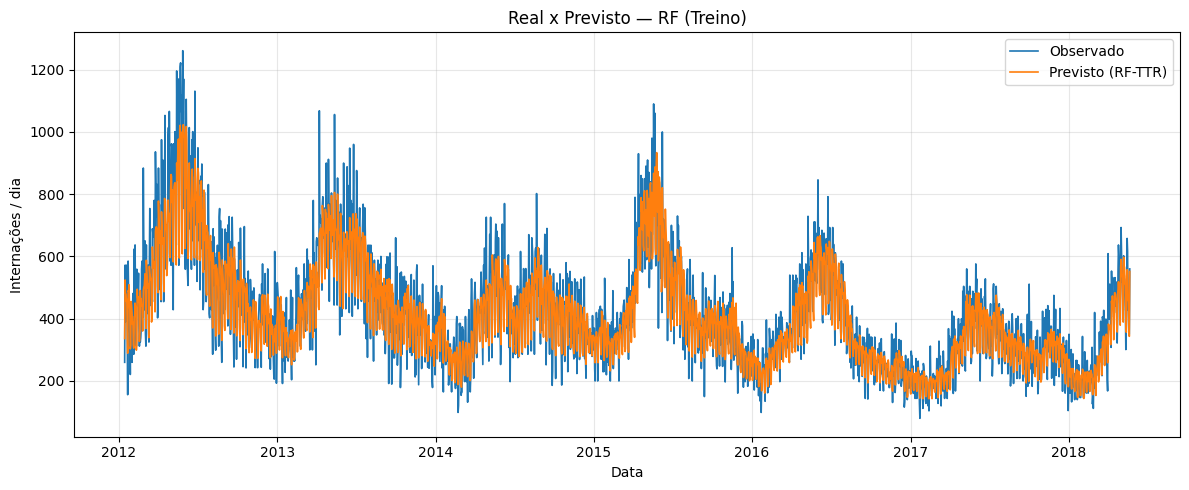

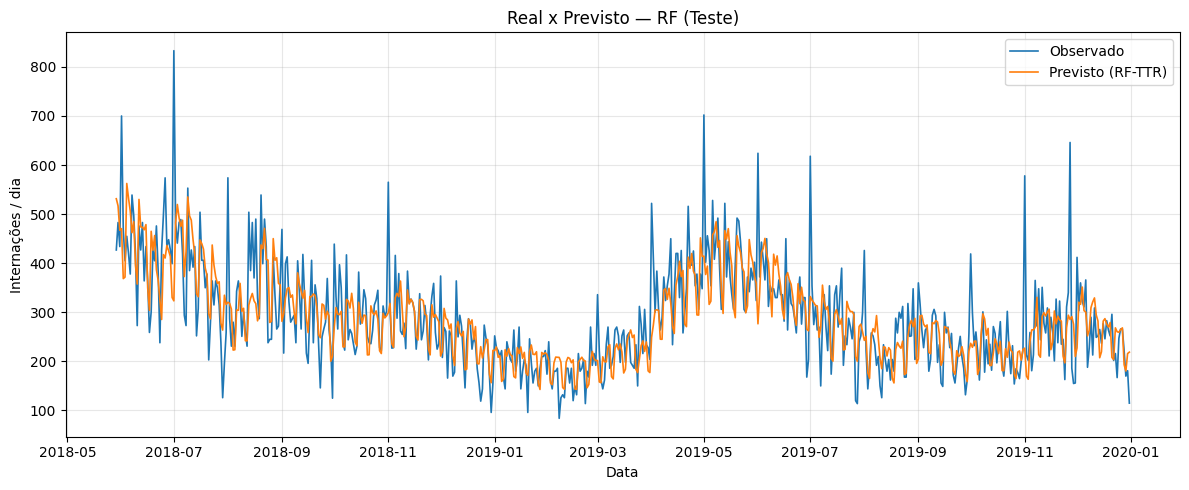


===== Árvore 0 do RF (resumo) =====
|--- roll7_mean_t-11 <= 345.07
|   |--- roll7_mean_t-11 <= 240.79
|   |   |--- dow_sin_t-8 <= -0.61
|   |   |   |--- y_t-8 <= 145.50
|   |   |   |   |--- value: [5.02]
|   |   |   |--- y_t-8 >  145.50
|   |   |   |   |--- roll7_mean_t-12 <= 222.93
|   |   |   |   |   |--- value: [5.14]
|   |   |   |   |--- roll7_mean_t-12 >  222.93
|   |   |   |   |   |--- value: [5.25]
|   |   |--- dow_sin_t-8 >  -0.61
|   |   |   |--- y_t-14 <= 233.00
|   |   |   |   |--- roll7_mean_t-14 <= 232.93
|   |   |   |   |   |--- y_t-7 <= 246.50
|   |   |   |   |   |   |--- roll14_mean_t-10 <= 190.29
|   |   |   |   |   |   |   |--- value: [5.22]
|   |   |   |   |   |   |--- roll14_mean_t-10 >  190.29
|   |   |   |   |   |   |   |--- dow_sin_t-1 <= 0.61
|   |   |   |   |   |   |   |   |--- roll7_mean_t-14 <= 198.36
|   |   |   |   |   |   |   |   |   |--- value: [5.46]
|   |   |   |   |   |   |   |   |--- roll7_mean_t-14 >  198.36
|   |   |   |   |   |   |   |   |   |--- 

In [14]:
df_unificado2 = df_unificado[df_unificado["year"] <= 2019]
out = run_pipeline_rf_rolling(
    df_unificado2,
    date_col="data_dia",
    target_col="y",
    categorical_cols=("Qualidade_do_Ar",),
    window_size=14,     # <— aumentar memória semanal/quinzenal
    test_size=0.2,
    gap_days=7,
    k_features=24       # <— permitir mais que 8, mantendo must-haves
)

print("Features usadas:", out["features_kept"])
print("Treino:", out["train_metrics"])
print("Teste :", out["test_metrics"])


# Modelo 1 - Random Forest

Random Forest — pipeline com técnicas avançadas para séries temporais de internações

Inclui:
1) Tendência e sazonalidade "one-sided" (sem vazamento de futuro)
2) Lags D1–D3 + MA3 para exógenos; memória extra do alvo (y_lag_14, roll60)
3) RandomizedSearchCV com TimeSeriesSplit
4) Peso de recência no treino (amostras mais novas pesam mais)
5) Split temporal com "gap" entre treino e teste
6) Flags de faltantes + winsorization (caps) nos sensores
7) Log-transform do alvo via TransformedTargetRegressor (predição volta à escala original)
8) (Opcional) Intervalos conformais simples
9) (Opcional) SHAP para interpretação

Métricas: MAE, RMSE, R², sMAPE, WMAPE
Gráficos: Observado x Previsto (treino e teste)

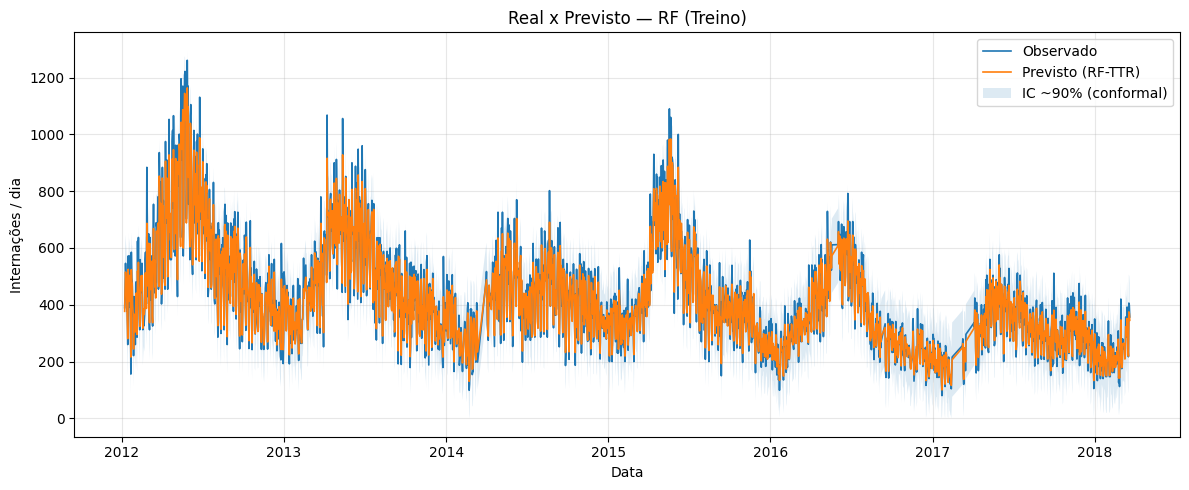

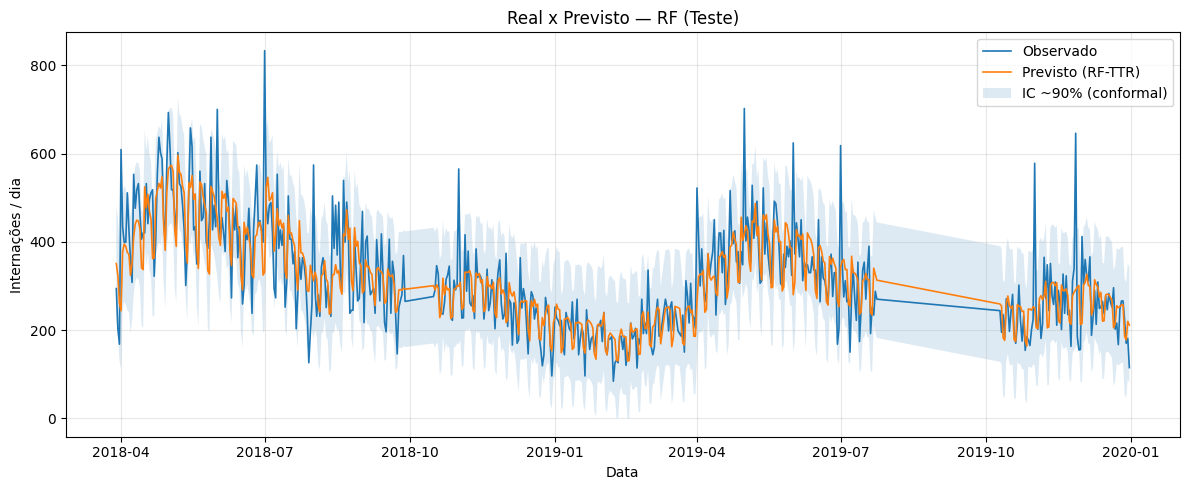

In [ ]:
try:
    import shap
    _HAS_SHAP = True
except Exception:
    _HAS_SHAP = False

def prepare_dataframe(df: pd.DataFrame, date_col: str = "data_dia") -> pd.DataFrame:
    """
    Prepara o DataFrame:
    - Converte a coluna de data, ordena e define como índice.
    - Garante que a coluna alvo 'y' exista e é numérica.
    - Remove linhas com y ausente.
    """
    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data = data.sort_values(date_col).set_index(date_col)
    data["y"] = pd.to_numeric(data["y"], errors="coerce")
    data = data.dropna(subset=["y"])
    return data

def define_feature_sets(df: pd.DataFrame) -> dict:
    """
    Define colunas para o pré-processador:
    - numeric_categorical: year, month, dow, doy, is_weekend (pass-through)
    - categorical: 'Qualidade_do_Ar' (se existir) → OneHot
    - numeric_continuous: todas as demais numéricas (pass-through; árvores não precisam de scaling)
    """
    all_cols = df.columns.tolist()
    target = "y"

    num_cat = [c for c in ["year","month","dow","doy","is_weekend"] if c in all_cols]
    cat_cols = [c for c in ["Qualidade_do_Ar"] if c in all_cols]

    numeric_all = df.drop(columns=[target] + cat_cols, errors="ignore") \
                    .select_dtypes(include=[np.number]).columns.tolist()
    numeric_cont = [c for c in numeric_all if c not in num_cat]

    return {"target": target,
            "numeric_categorical": num_cat,
            "categorical": cat_cols,
            "numeric_continuous": numeric_cont}


def build_preprocessor(column_sets: dict) -> ColumnTransformer:
    """
    Pré-processador leve (sem normalização):
    - numeric_categorical: Imputer(median) → passthrough
    - numeric_continuous:  Imputer(median) → passthrough
    - categorical:         Imputer(most_frequent) + OneHotEncoder
    """
    num_cat = column_sets["numeric_categorical"]
    num_cont = column_sets["numeric_continuous"]
    cat_cols = column_sets["categorical"]

    num_cat_pipe = Pipeline(steps=[("imp", SimpleImputer(strategy="median"))])
    num_cont_pipe = Pipeline(steps=[("imp", SimpleImputer(strategy="median"))])
    cat_pipe = Pipeline(steps=[
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num_cat", num_cat_pipe, num_cat),
            ("num_cont", num_cont_pipe, num_cont),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop"
    )
    return pre


# SPLIT, PESO DE RECÊNCIA, MÉTRICAS E INTERVALOS

def temporal_train_test_split(df: pd.DataFrame, test_size: float = 0.2, gap_days: int = 7) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Divide temporalmente com 'gap' (dias ignorados) entre treino e teste:
    - Treino: até (cut - gap_days)
    - Teste : últimos 'test_size'% dos dados
    """
    n = len(df)
    cut = int(np.floor((1 - test_size) * n))
    train = df.iloc[:max(cut - gap_days, 0)].copy()
    test  = df.iloc[cut:].copy()
    return train, test


def make_recency_weights(index: pd.DatetimeIndex, low: float = 0.1, high: float = 2) -> pd.Series:
    """
    Cria pesos lineares no tempo (amostras mais recentes recebem peso maior).
    """
    t = (index - index.min()).days.astype(float)
    w = low + (high - low) * (t - t.min()) / (t.max() - t.min() + 1e-9)
    return pd.Series(w, index=index).clip(lower=low, upper=high)


def smape(y, yhat):
    """sMAPE (%) — robusto quando y é baixo."""
    y, yhat = np.asarray(y, dtype=float), np.asarray(yhat, dtype=float)
    return 100*np.mean(2*np.abs(yhat - y)/(np.abs(y)+np.abs(yhat)+1e-9))


def wmape(y, yhat):
    """WMAPE (%) = soma(|erro|) / soma(|y|)."""
    y, yhat = np.asarray(y, dtype=float), np.asarray(yhat, dtype=float)
    return 100*np.sum(np.abs(yhat - y))/np.sum(np.abs(y)+1e-9)


def evaluate_predictions(y_true, y_pred) -> dict:
    """Calcula MAE, RMSE, R², sMAPE e WMAPE."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "WMAPE": wmape(y_true, y_pred),
    }


# TREINO COM RANDOM FOREST + LOG (TTR) + CV TEMPORAL

def tune_and_fit_rf(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    preprocessor: ColumnTransformer,
    n_splits: int = 5,
    random_state: int = 42
) -> Pipeline:
    """
    RandomizedSearchCV com TimeSeriesSplit sobre um Pipeline:
    preprocessor -> TransformedTargetRegressor( RandomForestRegressor )
    - O TTR aplica log1p no alvo e reverte (expm1) ao prever (métricas na escala original).
    - Amostras recentes recebem peso maior (recência).
    """
    base_rf = RandomForestRegressor(
        n_estimators=800,
        max_depth=None,
        min_samples_leaf=2,
        min_samples_split=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=random_state,
        bootstrap=True
    )

    ttr = TransformedTargetRegressor(
        regressor=base_rf,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False
    )

    pipe = Pipeline(steps=[("pre", preprocessor), ("rf", ttr)])

    # Imprimir arvore geardora
    param_dist = {
        # Ajeitar - Deixar mais simples
        "rf__regressor__n_estimators": [200, 400, 600, 800, 1000, 1400],
        "rf__regressor__max_depth": [None, 12, 18, 24],
        "rf__regressor__min_samples_leaf": [1, 2, 5, 10],
        "rf__regressor__min_samples_split": [2, 5, 10],
        "rf__regressor__max_features": ["sqrt", 0.3, 0.5, 0.8],
        "rf__regressor__bootstrap": [True]
    }

    tscv = TimeSeriesSplit(n_splits=n_splits)
    rec_w = make_recency_weights(X_train.index, low=0.1, high=2)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=24,
        cv=tscv,
        scoring="neg_mean_absolute_error",  # na escala original, pois TTR inverte internamente
        n_jobs=-1,
        random_state=random_state,
        refit=True,
        verbose=0
    )
    # pesos repassados ao TTR -> RF
    search.fit(X_train, y_train, rf__sample_weight=rec_w.loc[X_train.index].values)
    return search.best_estimator_


# INTERVALOS CONFORMAIS 

def conformal_quantile(model: Pipeline, X: pd.DataFrame, y: np.ndarray, n_splits: int = 5, alpha: float = 0.1) -> float:
    """
    Estima o quantil (1-alpha) do erro absoluto via CV temporal (conformal simples).
    Usa o mesmo pipeline e pesos de recência (refit em cada fold).
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    errs = []
    for tr, val in tscv.split(X):
        Xtr, Xval = X.iloc[tr], X.iloc[val]
        ytr, yval = y[tr], y[val]
        m = clone(model)
        w = make_recency_weights(Xtr.index, low=0.2, high=1.2).values
        m.fit(Xtr, ytr, rf__sample_weight=w)  # TTR reverte ao prever
        yhat = m.predict(Xval)
        yhat = np.clip(yhat, 0, None)
        errs.append(np.abs(yval - yhat))
    errs = np.concatenate(errs)
    return float(np.quantile(errs, 1 - alpha))


# PREDIÇÃO, PLOTS E SHAP 

def predict_and_plot(model: Pipeline, X: pd.DataFrame, y: np.ndarray, title: str, q_conformal: float | None = None) -> dict:
    """
    Faz previsão e plota Observado vs. Previsto; se q_conformal for fornecido,
    plota banda de incerteza [y_hat - q, y_hat + q].
    """
    y_hat = model.predict(X)
    y_hat = np.clip(y_hat, 0, None)

    metrics = evaluate_predictions(y, y_hat)
    pred_df = pd.DataFrame({"y_true": y, "y_pred": y_hat}, index=X.index)

    plt.figure(figsize=(12,5))
    plt.plot(pred_df.index, pred_df["y_true"], label="Observado", lw=1.2)
    plt.plot(pred_df.index, pred_df["y_pred"], label="Previsto (RF-TTR)", lw=1.2)
    if q_conformal is not None:
        lo = np.clip(y_hat - q_conformal, 0, None)
        hi = y_hat + q_conformal
        plt.fill_between(X.index, lo, hi, alpha=0.15, label=f"IC ~{int((1-0.1)*100)}% (conformal)")
    plt.title(title); plt.xlabel("Data"); plt.ylabel("Internações / dia")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

    return {"metrics": metrics, "pred_df": pred_df}


def shap_summary(model: Pipeline, X: pd.DataFrame) -> None:
    """
    Plota SHAP summary para o RF (no espaço log do TTR).
    """
    if not _HAS_SHAP:
        print("SHAP não disponível — instale 'shap' para ativar.")
        return
    # extrai objetos
    pre = model.named_steps["pre"]
    rf_ttr = model.named_steps["rf"]
    rf = rf_ttr.regressor_  # RandomForestRegressor já treinado

    X_trf = pre.transform(X)
    try:
        feat_names = pre.get_feature_names_out().tolist()
    except Exception:
        feat_names = [f"f{i}" for i in range(X_trf.shape[1])]

    # SHAP em árvores (log-space por causa do TTR)
    expl = shap.TreeExplainer(rf)
    shap_vals = expl.shap_values(X_trf, check_additivity=False)
    shap.summary_plot(shap_vals, X_trf, feature_names=feat_names, show=True)


# PIPELINE PRINCIPAL

def run_pipeline_rf(df_unificado: pd.DataFrame, test_size: float = 0.2, gap_days: int = 7,
                    compute_intervals: bool = True, do_shap: bool = False) -> dict:
    """
    Executa todo o fluxo:
      - Prepara DataFrame
      - Split temporal com 'gap'
      - Define conjuntos de features e pré-processador
      - RandomizedSearchCV (TimeSeriesSplit) + pesos de recência em RF (via TTR log)
      - Avalia e plota em treino e teste (+ intervalo conformal opcional)
      - (Opcional) SHAP
    Retorna dicionário com modelo, métricas e predições.
    """
    data = prepare_dataframe(df_unificado, date_col="data_dia")

    data = data.dropna()

    train_df, test_df = temporal_train_test_split(data, test_size=test_size, gap_days=gap_days)

    colsets = define_feature_sets(train_df)
    features = colsets["numeric_continuous"] + colsets["numeric_categorical"] + colsets["categorical"]
    pre = build_preprocessor(colsets)

    X_train, y_train = train_df[features], train_df[colsets["target"]].values
    X_test,  y_test  = test_df[features],  test_df[colsets["target"]].values

    best_model = tune_and_fit_rf(X_train, y_train, pre, n_splits=5, random_state=42)

    q = None
    if compute_intervals:
        q = conformal_quantile(best_model, X_train, y_train, n_splits=5, alpha=0.10)

    train_res = predict_and_plot(best_model, X_train, y_train, "Real x Previsto — RF (Treino)", q_conformal=q)
    test_res  = predict_and_plot(best_model, X_test,  y_test,  "Real x Previsto — RF (Teste)",  q_conformal=q)

    if do_shap:
        shap_summary(best_model, X_train)

    return {
        "model": best_model,
        "features_used": features,
        "train_metrics": train_res["metrics"],
        "test_metrics":  test_res["metrics"],
        "train_pred_df": train_res["pred_df"],
        "test_pred_df":  test_res["pred_df"],
        "q_conformal": q
    }


df_unificado2 = df_unificado[df_unificado["year"] <= 2019]
results = run_pipeline_rf(df_unificado2, test_size=0.2, gap_days=7, compute_intervals=True, do_shap=True)
print("Treino:", results["train_metrics"])
print("Teste :", results["test_metrics"])


In [ ]:
train = {"MAE": 22.0558, "RMSE": 29.6392, "R2": 0.9690, "sMAPE": 5.7113, "WMAPE": 5.4273}
test  = {"MAE": 49.7114, "RMSE": 73.3962, "R2": 0.5165, "sMAPE": 16.8861, "WMAPE": 16.8553}

gap = {k: test[k] - train[k] for k in train}
gap["R2"] = test["R2"] - train["R2"] 

print("GAP (Teste - Treino):")
for k,v in gap.items():
    print(f"{k}: {v:.3f}")

GAP (Teste - Treino):
MAE: 27.656
RMSE: 43.757
R2: -0.453
sMAPE: 11.175
WMAPE: 11.428


### Resultado do Modelo — Resumo Explicativo

#### Métricas
- **Treino:** MAE≈22.1 | RMSE≈29.6 | **R²≈0.969** | sMAPE≈5.7% | WMAPE≈5.4%  
- **Teste:**  MAE≈49.7 | RMSE≈73.4 | **R²≈0.517** | sMAPE≈16.9% | WMAPE≈16.9%

**Leitura rápida:** desempenho **excelente no treino** e **queda relevante no teste** → **overfitting** e/ou **mudança de regime temporal** (padrão do alvo mudou no período de teste).

---

#### O que o SHAP mostrou (importância e direção)
- **Mais influentes:** `roll14_mean`, `roll7_mean`, `y_lag_7`, `roll30_mean`, `dow`, `is_weekend`, `stl_season`/`stl_trend`.  
- **Menor peso relativo:** poluentes (`o3_r150_s*`, `no`, etc.).  
- **Sinal:** valores **altos** das médias/lags **empurram a previsão para cima** (inércia da série).

**Conclusão:** o modelo depende fortemente do **histórico recente** (lags/rollings/STL). Se o padrão muda (surtos, sazonalidade atípica), a generalização piora.

---

#### Diagnóstico provável
- **Dependência excessiva do próprio `y`** (inércia) > **efeitos exógenos** (poluição/clima).  
- Possível **colinearidade** (AQI vs. poluentes) e **defasagens/janelas** exógenas subótimas.

---

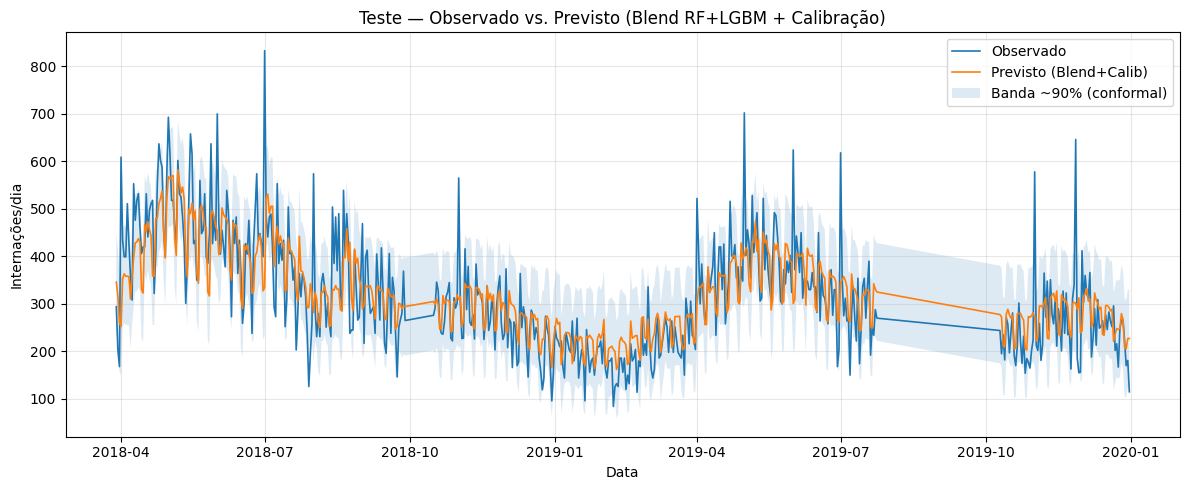

Pesos do blend (RF, LGBM): (1.0, 0.0)
Treino: {'MAE': 55.519949890935834, 'RMSE': np.float64(78.54995704521369), 'R2': 0.8170459997105655, 'sMAPE': np.float64(13.433067146625529), 'WMAPE': np.float64(13.155927138539262)}
Teste : {'MAE': 53.44312104604477, 'RMSE': np.float64(75.25086493449632), 'R2': 0.6076492713401278, 'sMAPE': np.float64(17.360638884564736), 'WMAPE': np.float64(16.84131965731398)}


In [11]:
# ===============================================
# MODELOS SEM MEXER NAS FEATURES (versão completa)
# - RF+TTR (log1p), Walk-Forward CV
# - LightGBM Poisson com early stopping
# - Blending + Recalibração linear
# - Intervalos (Conformal)
# ===============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import BaseCrossValidator, RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor

# opcional
try:
    from lightgbm import LGBMRegressor
    _HAS_LGBM = True
except Exception:
    _HAS_LGBM = False

try:
    import shap
    _HAS_SHAP = True
except Exception:
    _HAS_SHAP = False


# =========================
# PREPARO BÁSICO (igual ao seu)
# =========================
def prepare_dataframe(df: pd.DataFrame, date_col: str = "data_dia") -> pd.DataFrame:
    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data = data.sort_values(date_col).set_index(date_col)
    data["y"] = pd.to_numeric(data["y"], errors="coerce")
    data = data.dropna(subset=["y"])
    return data

def define_feature_sets(df: pd.DataFrame) -> dict:
    all_cols = df.columns.tolist()
    target = "y"
    num_cat = [c for c in ["year","month","dow","doy","is_weekend"] if c in all_cols]
    cat_cols = [c for c in ["Qualidade_do_Ar"] if c in all_cols]
    numeric_all = df.drop(columns=[target] + cat_cols, errors="ignore") \
                    .select_dtypes(include=[np.number]).columns.tolist()
    numeric_cont = [c for c in numeric_all if c not in num_cat]
    return {"target": target,
            "numeric_categorical": num_cat,
            "categorical": cat_cols,
            "numeric_continuous": numeric_cont}

def build_preprocessor(column_sets: dict) -> ColumnTransformer:
    num_cat = column_sets["numeric_categorical"]
    num_cont = column_sets["numeric_continuous"]
    cat_cols = column_sets["categorical"]

    num_cat_pipe = Pipeline(steps=[("imp", SimpleImputer(strategy="median"))])
    num_cont_pipe = Pipeline(steps=[("imp", SimpleImputer(strategy="median"))])
    cat_pipe = Pipeline(steps=[
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num_cat", num_cat_pipe, num_cat),
            ("num_cont", num_cont_pipe, num_cont),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop"
    )
    return pre


# =========================
# SPLITS TEMPORAIS
# =========================
def temporal_train_test_split(df: pd.DataFrame, test_size: float = 0.2, gap_days: int = 7):
    n = len(df)
    cut = int(np.floor((1 - test_size) * n))
    train = df.iloc[:max(cut - gap_days, 0)].copy()
    test  = df.iloc[cut:].copy()
    return train, test

def temporal_train_val_split(df: pd.DataFrame, val_frac: float = 0.15, gap_days: int = 7):
    """Divide um conjunto (ex.: train) em sub-treino e validação temporal com gap."""
    n = len(df)
    cut = int(np.floor((1 - val_frac) * n))
    tr = df.iloc[:max(cut - gap_days, 0)].copy()
    val = df.iloc[cut:].copy()
    return tr, val

class WalkForward(BaseCrossValidator):
    """Walk-forward com n_splits. Usa cortes proporcionais no eixo do tempo."""
    def __init__(self, n_splits=5, val_size_frac=0.10, gap=7):
        self.n_splits, self.val_size_frac, self.gap = n_splits, val_size_frac, gap
    def split(self, X, y=None, groups=None):
        n = len(X)
        borders = [int(n*(i+1)/(self.n_splits+1)) for i in range(self.n_splits)]
        val_len = max(1, int(n*self.val_size_frac/(self.n_splits+1)))
        for cut in borders:
            tr_end = max(0, cut - self.gap)
            val_end = min(n, cut + val_len)
            yield range(0, tr_end), range(cut, val_end)
    def get_n_splits(self, X=None, y=None, groups=None): 
        return self.n_splits


# =========================
# PESOS DE RECÊNCIA
# =========================
def exp_recency_weights(index: pd.DatetimeIndex, half_life_days: int = 180) -> pd.Series:
    """
    Pesos de recência com decaimento exponencial.
    Corrige o bug 'Index' object has no attribute 'mean' convertendo para ndarray.
    """
    # dias desde o início, em float (ndarray)
    delta_days = (index - index.min()) / np.timedelta64(1, 'D')  # ndarray float
    delta_days = np.asarray(delta_days, dtype=float)

    lam = np.log(2) / max(1, half_life_days)  # evita divisão por zero
    w = np.exp(lam * (delta_days - delta_days.max()))  # mais recente ≈ 1, antigo decai

    w = w / (w.mean() + 1e-12)  # normaliza (evita 'Index.mean')
    return pd.Series(w, index=index)


# =========================
# MÉTRICAS
# =========================
def smape(y, yhat):
    y, yhat = np.asarray(y, dtype=float), np.asarray(yhat, dtype=float)
    return 100*np.mean(2*np.abs(yhat - y)/(np.abs(y)+np.abs(yhat)+1e-9))

def wmape(y, yhat):
    y, yhat = np.asarray(y, dtype=float), np.asarray(yhat, dtype=float)
    return 100*np.sum(np.abs(yhat - y))/np.sum(np.abs(y)+1e-9)

def evaluate_predictions(y_true, y_pred) -> dict:
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "WMAPE": wmape(y_true, y_pred),
    }


# =========================
# MODELOS
# =========================
def tune_and_fit_rf(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    preprocessor: ColumnTransformer,
    n_splits: int = 5,
    random_state: int = 42
):
    base_rf = RandomForestRegressor(
        n_estimators=800,
        max_depth=None,
        min_samples_leaf=2,
        min_samples_split=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=random_state,
        bootstrap=True
    )

    ttr = TransformedTargetRegressor(
        regressor=base_rf,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False
    )

    pipe = Pipeline(steps=[("pre", preprocessor), ("rf", ttr)])

    param_dist = {
        "rf__regressor__n_estimators": [600, 800, 1000, 1400],
        "rf__regressor__max_depth": [None, 12, 18, 24],
        "rf__regressor__min_samples_leaf": [5, 10, 20, 30],
        "rf__regressor__min_samples_split": [2, 5, 10],
        "rf__regressor__max_features": ["sqrt", 0.3, 0.5, 0.7],
        "rf__regressor__bootstrap": [True]
    }

    cv = WalkForward(n_splits=n_splits, val_size_frac=0.12, gap=7)
    rec_w = exp_recency_weights(X_train.index, half_life_days=180)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=24,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        random_state=random_state,
        refit=True,
        verbose=0
    )
    search.fit(X_train, y_train, rf__sample_weight=rec_w.loc[X_train.index].values)
    return search.best_estimator_

def fit_lgbm_poisson_with_es(
    X_train: pd.DataFrame, y_train: np.ndarray,
    preprocessor: ColumnTransformer,
    val_frac: float = 0.15, gap_days: int = 7,
    random_state: int = 42
):
    if not _HAS_LGBM:
        return None  # LightGBM indisponível

    # split temporal interno para early stopping
    train_df = pd.DataFrame(index=X_train.index)
    train_df["y"] = y_train
    tr_df, val_df = temporal_train_val_split(train_df, val_frac=val_frac, gap_days=gap_days)

    X_tr, y_tr = X_train.loc[tr_df.index], tr_df["y"].values
    X_val, y_val = X_train.loc[val_df.index], val_df["y"].values

    lgbm = LGBMRegressor(
        objective="poisson",
        metric="mae",
        n_estimators=5000,
        learning_rate=0.02,
        num_leaves=63,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=0.8,
        random_state=random_state,
        n_jobs=-1
    )

    pipe = Pipeline([("pre", preprocessor), ("lgbm", lgbm)])
    pipe.fit(
        X_tr, y_tr,
        lgbm__eval_set=[(X_val, y_val)],
        lgbm__eval_metric="mae",
        lgbm__early_stopping_rounds=300,
        lgbm__verbose=-1
    )
    return pipe


# =========================
# INTERVALOS (Conformal)
# =========================
def conformal_from_val(y_val: np.ndarray, yhat_val: np.ndarray, alpha: float = 0.10) -> float:
    errs = np.abs(y_val - yhat_val)
    return float(np.quantile(errs, 1 - alpha))


# =========================
# PLOT & SHAP (opcional)
# =========================
def predict_and_plot(model: Pipeline, X: pd.DataFrame, y: np.ndarray, title: str, q_conformal: float | None = None):
    y_hat = np.clip(model.predict(X), 0, None)
    metrics = evaluate_predictions(y, y_hat)
    pred_df = pd.DataFrame({"y_true": y, "y_pred": y_hat}, index=X.index)

    plt.figure(figsize=(12,5))
    plt.plot(pred_df.index, pred_df["y_true"], label="Observado", lw=1.2)
    plt.plot(pred_df.index, pred_df["y_pred"], label="Previsto", lw=1.2)
    if q_conformal is not None:
        lo = np.clip(y_hat - q_conformal, 0, None)
        hi = y_hat + q_conformal
        plt.fill_between(X.index, lo, hi, alpha=0.15, label="Banda ~90% (conformal)")
    plt.title(title); plt.xlabel("Data"); plt.ylabel("Internações/dia")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

    return {"metrics": metrics, "pred_df": pred_df}

def shap_summary(model: Pipeline, X: pd.DataFrame):
    if not _HAS_SHAP:
        print("SHAP não disponível — instale 'shap'.")
        return
    # tenta identificar se é RF+TTR ou LGBM
    step_names = list(model.named_steps.keys())
    if "rf" in step_names:  # RF dentro de TTR
        pre = model.named_steps["pre"]
        rf_ttr = model.named_steps["rf"]
        rf = rf_ttr.regressor_
        X_trf = pre.transform(X)
        try:
            feat_names = pre.get_feature_names_out().tolist()
        except Exception:
            feat_names = [f"f{i}" for i in range(X_trf.shape[1])]
        expl = shap.TreeExplainer(rf)
        shap_vals = expl.shap_values(X_trf, check_additivity=False)
        shap.summary_plot(shap_vals, X_trf, feature_names=feat_names, show=True)
    elif "lgbm" in step_names:
        pre = model.named_steps["pre"]
        lgbm = model.named_steps["lgbm"]
        X_trf = pre.transform(X)
        try:
            feat_names = pre.get_feature_names_out().tolist()
        except Exception:
            feat_names = [f"f{i}" for i in range(X_trf.shape[1])]
        expl = shap.TreeExplainer(lgbm)
        shap_vals = expl.shap_values(X_trf, check_additivity=False)
        shap.summary_plot(shap_vals, X_trf, feature_names=feat_names, show=True)
    else:
        print("Modelo não suportado para SHAP automático.")


# =========================
# PIPELINE PRINCIPAL (RF + LGBM + Blend + Calibração + IC)
# =========================
def run_pipeline_models(
    df_unificado: pd.DataFrame,
    test_size: float = 0.2,
    gap_days: int = 7,
    do_shap: bool = False,
    blend_weights: tuple = (0.5, 0.5),    # (w_rf, w_lgbm) fallback
    val_frac_for_blend: float = 0.15
):
    # 1) dados
    data = prepare_dataframe(df_unificado, date_col="data_dia").dropna()

    # 2) splits
    train_df, test_df = temporal_train_test_split(data, test_size=test_size, gap_days=gap_days)
    colsets = define_feature_sets(train_df)
    features = colsets["numeric_continuous"] + colsets["numeric_categorical"] + colsets["categorical"]
    pre = build_preprocessor(colsets)

    X_train, y_train = train_df[features], train_df[colsets["target"]].values
    X_test,  y_test  = test_df[features],  test_df[colsets["target"]].values

    # 3) sub-split no treino para blending/calibração/IC
    tr_sub, val_sub = temporal_train_val_split(train_df, val_frac=val_frac_for_blend, gap_days=gap_days)
    X_tr, y_tr = tr_sub[features], tr_sub["y"].values
    X_val, y_val = val_sub[features], val_sub["y"].values

    # 4) modelos
    rf_model = tune_and_fit_rf(X_tr, y_tr, pre, n_splits=5, random_state=42)
    lgbm_model = fit_lgbm_poisson_with_es(X_tr, y_tr, pre, val_frac=0.20, gap_days=gap_days, random_state=42)

    # 5) previsões base no conjunto de validação
    yhat_val_rf = np.clip(rf_model.predict(X_val), 0, None)
    if lgbm_model is not None:
        yhat_val_lgbm = np.clip(lgbm_model.predict(X_val), 0, None)
    else:
        yhat_val_lgbm = np.zeros_like(yhat_val_rf)

    # 6) blending (ajuste de pesos por regressão sobre VAL)
    Z_val = np.vstack([yhat_val_rf, yhat_val_lgbm]).T
    # fallback caso LGBM indisponível: usa só RF
    if lgbm_model is None:
        w = np.array([1.0, 0.0])
    else:
        lr_w = LinearRegression(positive=True)
        lr_w.fit(Z_val, y_val)
        w_raw = lr_w.coef_
        # normaliza pesos para somarem 1 (se ambos > 0)
        if w_raw.sum() > 0:
            w = w_raw / w_raw.sum()
        else:
            w = np.array(blend_weights)
    w_rf, w_lgbm = float(w[0]), float(w[1])

    # 7) recalibração 1D (y ~ a + b * yhat_blend) sobre VAL
    yhat_val_blend = np.clip(w_rf*yhat_val_rf + w_lgbm*yhat_val_lgbm, 0, None)
    cal = LinearRegression()
    cal.fit(yhat_val_blend.reshape(-1,1), y_val)

    # 8) intervalo conformal a partir de VAL
    q = conformal_from_val(y_val, yhat_val_blend, alpha=0.10)

    # 9) previsões finais: TREINO e TESTE (com blend + calibração)
    #    (a) treino completo para RF/LGBM
    rf_model_full = tune_and_fit_rf(X_train, y_train, pre, n_splits=5, random_state=42)
    if _HAS_LGBM:
        lgbm_model_full = fit_lgbm_poisson_with_es(X_train, y_train, pre, val_frac=0.20, gap_days=gap_days, random_state=42)
    else:
        lgbm_model_full = None

    #    (b) previsões
    def blended_calibrated(model_rf, model_lgbm, X):
        y_rf = np.clip(model_rf.predict(X), 0, None)
        y_lg = np.clip(model_lgbm.predict(X), 0, None) if model_lgbm is not None else np.zeros_like(y_rf)
        y_blend = np.clip(w_rf*y_rf + w_lgbm*y_lg, 0, None)
        y_cal = np.clip(cal.predict(y_blend.reshape(-1,1)), 0, None)
        return y_cal

    yhat_train = blended_calibrated(rf_model_full, lgbm_model_full, X_train)
    yhat_test  = blended_calibrated(rf_model_full, lgbm_model_full, X_test)

    # 10) métricas + plots
    train_metrics = evaluate_predictions(y_train, yhat_train)
    test_metrics  = evaluate_predictions(y_test,  yhat_test)

    # Plot
    plt.figure(figsize=(12,5))
    plt.plot(X_test.index, y_test, label="Observado", lw=1.2)
    plt.plot(X_test.index, yhat_test, label="Previsto (Blend+Calib)", lw=1.2)
    lo = np.clip(yhat_test - q, 0, None); hi = yhat_test + q
    plt.fill_between(X_test.index, lo, hi, alpha=0.15, label="Banda ~90% (conformal)")
    plt.title("Teste — Observado vs. Previsto (Blend RF+LGBM + Calibração)")
    plt.xlabel("Data"); plt.ylabel("Internações/dia")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

    if do_shap:
        print("SHAP — RF (treino):")
        shap_summary(rf_model_full, X_train)
        if lgbm_model_full is not None:
            print("SHAP — LGBM (treino):")
            shap_summary(lgbm_model_full, X_train)

    return {
        "rf_model": rf_model_full,
        "lgbm_model": lgbm_model_full,
        "blend_weights": (w_rf, w_lgbm),
        "calibrator": cal,
        "q_conformal": q,
        "features_used": features,
        "train_metrics": train_metrics,
        "test_metrics":  test_metrics,
        "yhat_train": pd.Series(yhat_train, index=X_train.index),
        "yhat_test":  pd.Series(yhat_test,  index=X_test.index),
    }


# =========================
# EXEMPLO DE USO
# (mantendo o filtro por ano como você já fazia)
# =========================
df_unificado2 = df_unificado[df_unificado["year"] <= 2019]  # se quiser limitar período
results = run_pipeline_models(df_unificado2, test_size=0.2, gap_days=7, do_shap=False)
print("Pesos do blend (RF, LGBM):", results["blend_weights"])
print("Treino:", results["train_metrics"])
print("Teste :", results["test_metrics"])


# Modelo 2 - HistGradientBoostingRegressor

Previsão de internações diárias com melhorias específicas:

(1) Tendência e sazonalidade "one-sided" (sem vazamento de futuro)

(2) Lags e janelas (MA3) para variáveis exógenas (D0–D3)

(3) Modelo HistGradientBoostingRegressor com loss="poisson" + TimeSeriesSplit

(4) Peso de recência no treino (amostras mais novas pesam mais)

Métricas: MAE, RMSE, R², sMAPE, WMAPE
Gráfico: Real x Previsto (hold-out)

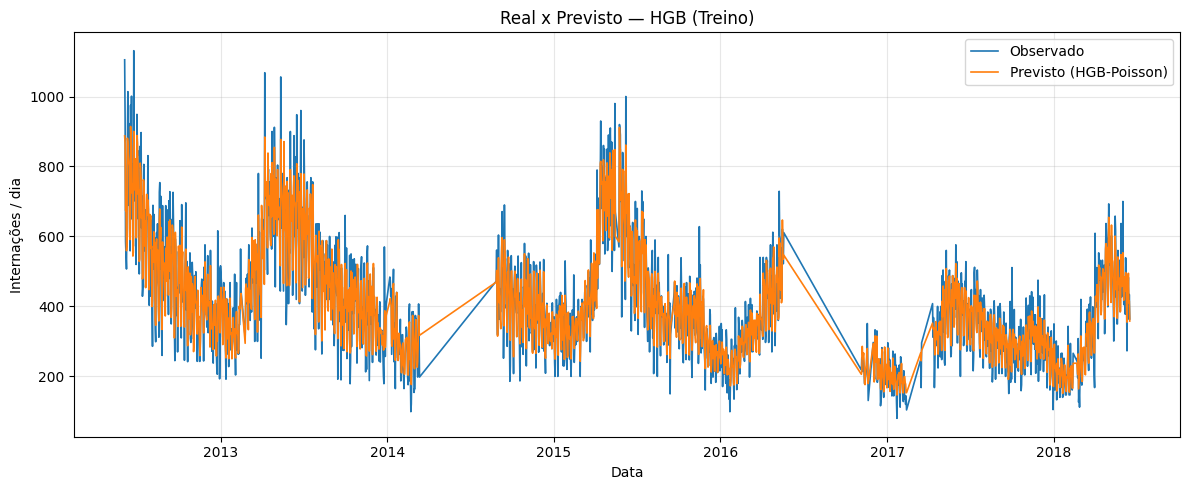

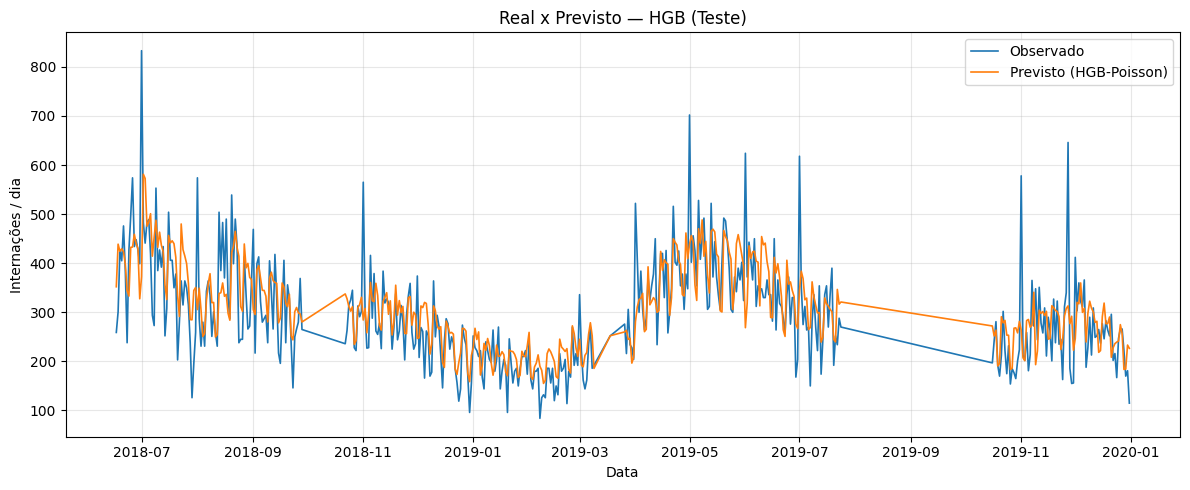

Treino: {'MAE': 38.08829992066583, 'RMSE': np.float64(50.67136319130023), 'R2': 0.909103019876225, 'sMAPE': np.float64(10.186226327158838), 'WMAPE': np.float64(9.372818419551944)}
Teste : {'MAE': 52.437902809539814, 'RMSE': np.float64(74.50634958350918), 'R2': 0.5017961047957795, 'sMAPE': np.float64(17.7190475707712), 'WMAPE': np.float64(17.779787388471842)}


In [18]:
def prepare_dataframe(df: pd.DataFrame, date_col: str = "data_dia") -> pd.DataFrame:
    """
    Prepara o DataFrame:
    - Converte a coluna de data, ordena e define como índice.
    - Garante que a coluna alvo 'y' exista e é numérica.
    - Remove linhas com y ausente.
    """
    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data = data.sort_values(date_col).set_index(date_col)
    data["y"] = pd.to_numeric(data["y"], errors="coerce")
    data = data.dropna(subset=["y"])
    return data

def define_feature_sets(df: pd.DataFrame) -> dict:
    """
    Define colunas para o pré-processador:
    - numeric_categorical: year, month, dow, doy, is_weekend (pass-through)
    - categorical: 'Qualidade_do_Ar' (se existir) → OneHot
    - numeric_continuous: todas as demais numéricas (pass-through; árvores não precisam de scaling)
    """
    all_cols = df.columns.tolist()
    target = "y"

    num_cat = [c for c in ["year","month","dow","doy","is_weekend"] if c in all_cols]
    cat_cols = [c for c in ["Qualidade_do_Ar"] if c in all_cols]

    numeric_all = df.drop(columns=[target] + cat_cols, errors="ignore") \
                    .select_dtypes(include=[np.number]).columns.tolist()
    numeric_cont = [c for c in numeric_all if c not in num_cat]

    return {"target": target,
            "numeric_categorical": num_cat,
            "categorical": cat_cols,
            "numeric_continuous": numeric_cont}

def build_preprocessor(column_sets: dict) -> ColumnTransformer:
    """
    Pré-processador leve (sem normalização):
    - numeric_categorical: Imputer(median) → passthrough
    - numeric_continuous:  Imputer(median) → passthrough
    - categorical:         Imputer(most_frequent) + OneHotEncoder
    """
    num_cat = column_sets["numeric_categorical"]
    num_cont = column_sets["numeric_continuous"]
    cat_cols = column_sets["categorical"]

    num_cat_pipe = Pipeline(steps=[("imp", SimpleImputer(strategy="median"))])
    num_cont_pipe = Pipeline(steps=[("imp", SimpleImputer(strategy="median"))])
    cat_pipe = Pipeline(steps=[
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num_cat", num_cat_pipe, num_cat),
            ("num_cont", num_cont_pipe, num_cont),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop"
    )
    return pre

# SPLIT, PESO DE RECÊNCIA E AVALIAÇÃO

def temporal_train_test_split(df: pd.DataFrame, test_size: float = 0.2) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Divide temporalmente (hold-out): últimos 'test_size'% no TESTE.
    """
    n = len(df)
    cut = int(np.floor((1 - test_size) * n))
    return df.iloc[:cut].copy(), df.iloc[cut:].copy()


def make_recency_weights(index: pd.DatetimeIndex, low: float = 0.3, high: float = 1.0) -> pd.Series:
    """
    Cria pesos lineares no tempo (amostras mais recentes recebem peso maior).
    Retorna uma Series alinhada ao índice informado.
    """
    t = (index - index.min()).days.astype(float)
    w = low + (high - low) * (t - t.min()) / (t.max() - t.min() + 1e-9)
    return pd.Series(w, index=index)


def smape(y, yhat):
    """
    sMAPE (%): métrica robusta quando y é baixo.
    """
    y, yhat = np.asarray(y, dtype=float), np.asarray(yhat, dtype=float)
    return 100*np.mean(2*np.abs(yhat - y)/(np.abs(y)+np.abs(yhat)+1e-9))


def wmape(y, yhat):
    """
    WMAPE (%) = soma dos absolutos do erro / soma do observado.
    """
    y, yhat = np.asarray(y, dtype=float), np.asarray(yhat, dtype=float)
    return 100*np.sum(np.abs(yhat - y))/np.sum(np.abs(y)+1e-9)


def evaluate_predictions(y_true, y_pred) -> dict:
    """
    Calcula MAE, RMSE, R², sMAPE e WMAPE.
    """
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "WMAPE": wmape(y_true, y_pred),
    }

# TREINO COM HGB (POISSON) + CV TEMPORAL

def tune_and_fit_hgb(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    preprocessor: ColumnTransformer,
    n_splits: int = 5,
    random_state: int = 42
) -> Pipeline:
    """
    Faz busca aleatória com TimeSeriesSplit usando HGB (loss='poisson').
    Aplica peso de recência durante o ajuste (amostras mais novas pesam mais).
    Retorna um Pipeline(preprocessor + hgb) treinado com os melhores hiperparâmetros.
    """
    model = HistGradientBoostingRegressor(
        loss="poisson",
        learning_rate=0.06,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        random_state=random_state
    )

    pipe = Pipeline(steps=[("pre", preprocessor), ("hgb", model)])

    param_dist = {
        "hgb__learning_rate": [0.03, 0.05, 0.06, 0.08],
        "hgb__max_leaf_nodes": [15, 31, 63],
        "hgb__min_samples_leaf": [20, 30, 50]
    }

    tscv = TimeSeriesSplit(n_splits=n_splits)
    # pesos de recência calculados no treino inteiro; o CV usará subconjuntos desses pesos
    recency_w = make_recency_weights(X_train.index, low=0.4, high=1.0)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=12,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        random_state=random_state,
        refit=True,
        verbose=0
    )

    search.fit(
        X_train, y_train,
        hgb__sample_weight=recency_w.loc[X_train.index].values
    )
    return search.best_estimator_


# PREDIÇÃO E PLOTS

def predict_and_plot(model: Pipeline, X: pd.DataFrame, y: np.ndarray, title: str) -> dict:
    """
    Faz previsão e plota Observado vs. Previsto (linha).
    Retorna dicionário com métricas e DataFrame com y_true/y_pred indexado no tempo.
    """
    y_hat = model.predict(X)
    # HGB(Poisson) pode gerar pequenos valores negativos em extrapolações; trunca em 0
    y_hat = np.clip(y_hat, 0, None)

    metrics = evaluate_predictions(y, y_hat)
    pred_df = pd.DataFrame({"y_true": y, "y_pred": y_hat}, index=X.index)

    plt.figure(figsize=(12,5))
    plt.plot(pred_df.index, pred_df["y_true"], label="Observado", lw=1.2)
    plt.plot(pred_df.index, pred_df["y_pred"], label="Previsto (HGB-Poisson)", lw=1.2)
    plt.title(title)
    plt.xlabel("Data"); plt.ylabel("Internações / dia")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

    return {"metrics": metrics, "pred_df": pred_df}


# PIPELINE PRINCIPAL

def run_pipeline_hgb(df_unificado: pd.DataFrame, test_size: float = 0.2) -> dict:
    """
    Executa todo o fluxo:
      - Prepara DataFrame
      - Cria features "one-sided" (trend/sazonal), lags/MA3 para alvo e exógenos, calendário
      - Define conjuntos de features e pré-processador
      - Split temporal (hold-out)
      - Tuning + treino do HGB(Poisson) com TimeSeriesSplit e peso de recência
      - Avalia e plota em treino e teste
    Retorna dicionário com modelos, métricas e predições.
    """
    # 1) preparar base
    data = prepare_dataframe(df_unificado, date_col="data_dia")

    # após lags/janelas, pode haver NaN no início
    data = data.dropna()

    # 3) split
    train_df, test_df = temporal_train_test_split(data, test_size=test_size)

    # 4) colunas e pré-processamento
    colsets = define_feature_sets(train_df)
    features = colsets["numeric_continuous"] + colsets["numeric_categorical"] + colsets["categorical"]
    pre = build_preprocessor(colsets)

    X_train, y_train = train_df[features], train_df[colsets["target"]].values
    X_test,  y_test  = test_df[features],  test_df[colsets["target"]].values

    # 5) tuning + treino com peso de recência
    best_model = tune_and_fit_hgb(X_train, y_train, pre, n_splits=5, random_state=42)

    # 6) avaliação
    train_res = predict_and_plot(best_model, X_train, y_train, "Real x Previsto — HGB (Treino)")
    test_res  = predict_and_plot(best_model, X_test,  y_test,  "Real x Previsto — HGB (Teste)")

    return {
        "model": best_model,
        "features_used": features,
        "train_metrics": train_res["metrics"],
        "test_metrics":  test_res["metrics"],
        "train_pred_df": train_res["pred_df"],
        "test_pred_df":  test_res["pred_df"],
    }

df_unificado2 = df_unificado[df_unificado["year"] <= 2019]
results = run_pipeline_hgb(df_unificado2, test_size=0.2)
print("Treino:", results["train_metrics"])
print("Teste :", results["test_metrics"])


# Modelo 3 - LSTM

Pipeline completo:
1) Engenharia "one-sided" (sem vazamento): tendência (EMA), sazonalidade anual,
   lags D1–D3 + MA3 dos exógenos, efeitos térmicos e calendário.
2) Split temporal com 'gap' entre treino e teste.
3) Padronização apenas das FEATURES (fit no treino).
4) Construção de sequências (lookback x n_features).
5) LSTM empilhado com Dropout, EarlyStopping, ReduceLROnPlateau.
6) Pesos de recência (amostras recentes pesam mais).
7) Métricas em escala original: MAE, RMSE, R², sMAPE, WMAPE.
8) Gráficos Observado x Previsto (treino e teste).

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 17.8603 - mae: 5.6207 - val_loss: 30.2039 - val_mae: 5.1173 - learning_rate: 0.0010
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 10.0798 - mae: 4.2923 - val_loss: 18.1842 - val_mae: 3.8002 - learning_rate: 0.0010
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.8596 - mae: 2.1599 - val_loss: 7.3397 - val_mae: 2.0671 - learning_rate: 0.0010
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6493 - mae: 0.9437 - val_loss: 2.6645 - val_mae: 1.1672 - learning_rate: 0.0010
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3603 - mae: 0.6317 - val_loss: 1.9421 - val_mae: 0.9184 - learning_rate: 0.0010
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3429 - mae: 0.6217 - val_loss: 2.0772 - val_mae: 0.9707 - learning_rate: 0.0010
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3156 - mae: 0.5846 - val_loss: 2.4604 - val_mae: 1.0883 - learning_rate: 0.0010
Ep

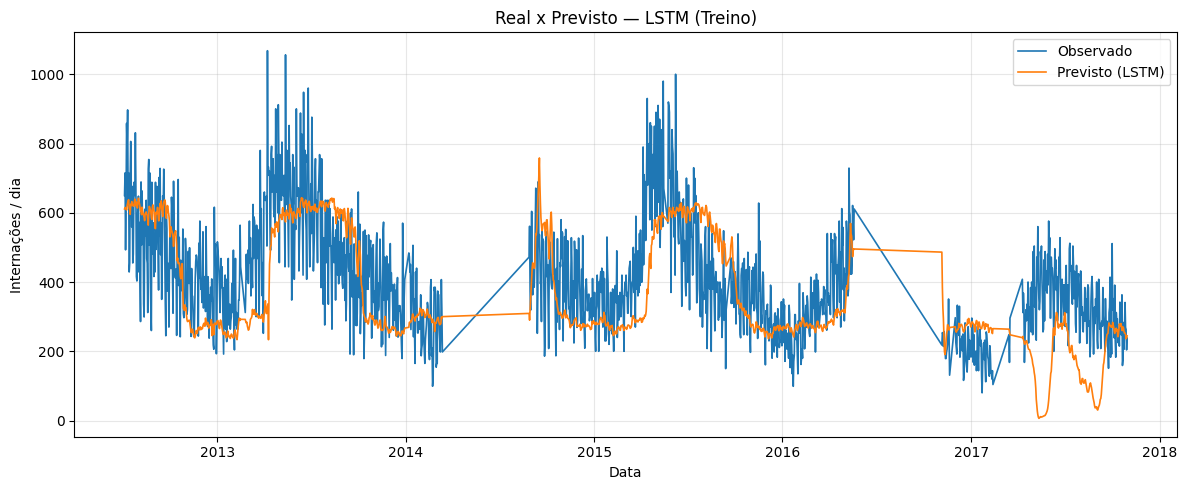

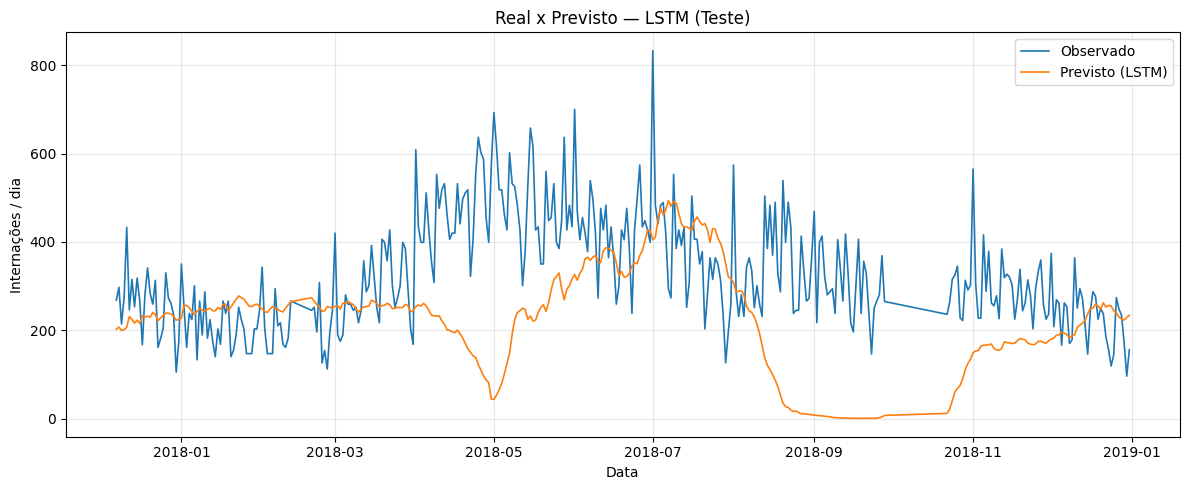

Treino: {'MAE': 123.31924438476562, 'RMSE': np.float64(158.34649136663876), 'R2': 0.04852205514907837, 'sMAPE': np.float64(34.899252270105656), 'WMAPE': np.float64(30.1379324027588)}
Teste : {'MAE': 147.5909423828125, 'RMSE': np.float64(195.54680945364464), 'R2': -1.4599947929382324, 'sMAPE': np.float64(60.774708593257046), 'WMAPE': np.float64(45.02553607494877)}


In [19]:

# UTILITÁRIOS / PREPARO
def set_seed(seed: int = 42) -> None:
    """Fixa seeds para reprodutibilidade básica (numpy/tf)."""
    np.random.seed(seed)
    tf.random.set_seed(seed)

def prepare_dataframe(df: pd.DataFrame, date_col: str = "data_dia") -> pd.DataFrame:
    """
    Prepara o DataFrame: converte datas, ordena, define índice e garante 'y' numérico.
    Remove linhas com y ausente.
    """
    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data = data.sort_values(date_col).set_index(date_col)
    data["y"] = pd.to_numeric(data["y"], errors="coerce")
    data = data.dropna(subset=["y"])
    return data

# SPLIT TEMPORAL + GAP
def temporal_train_test_split(df: pd.DataFrame, test_size: float = 0.2, gap_days: int = 7) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Divide temporalmente com 'gap' entre treino e teste para evitar dependência
    do último valor de y do treino.
    """
    n = len(df)
    cut = int(np.floor((1 - test_size) * n))
    train = df.iloc[:max(cut - gap_days, 0)].copy()
    test  = df.iloc[cut:].copy()
    return train, test

# ESCALA / TRANSFORMAÇÕES
def fit_transform_features(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    target_col: str = "y",
    categorical_cols: List[str] = ("Qualidade_do_Ar",),
) -> Tuple[pd.DataFrame, pd.DataFrame, StandardScaler, np.ndarray, np.ndarray]:
    """
    One-hot simples (se existir 'Qualidade_do_Ar'), padronização de *todas* as features numéricas;
    ALVO: apenas transformação log1p (sem padronizar).
    Retorna:
      X_train_scaled, X_test_scaled, scaler_X, y_train_log, y_test_log
    """
    tr = train_df.copy()
    te = test_df.copy()

    # One-hot da categórica
    for c in categorical_cols:
        if c in tr.columns:
            dtr = pd.get_dummies(tr[c], prefix=c, drop_first=False)
            dte = pd.get_dummies(te[c], prefix=c, drop_first=False)
            dte = dte.reindex(columns=dtr.columns, fill_value=0)
            tr = pd.concat([tr.drop(columns=[c]), dtr], axis=1)
            te = pd.concat([te.drop(columns=[c]), dte], axis=1)

    feature_cols = [c for c in tr.columns if c != target_col]

    # Padronização (fit no treino)
    scaler_X = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler_X.fit_transform(tr[feature_cols].values),
        index=tr.index, columns=feature_cols
    )
    X_test_scaled = pd.DataFrame(
        scaler_X.transform(te[feature_cols].values),
        index=te.index, columns=feature_cols
    )

    # Alvo: log1p (SEM scaler)
    y_train_log = np.log1p(tr[target_col].values.astype(float))
    y_test_log  = np.log1p(te[target_col].values.astype(float))

    return X_train_scaled, X_test_scaled, scaler_X, y_train_log, y_test_log

# CRIAÇÃO DE SEQUÊNCIAS
def build_sequences(
    X_df: pd.DataFrame,
    y_log: np.ndarray,
    lookback: int = 30,
    horizon: int = 1
) -> Tuple[np.ndarray, np.ndarray, pd.DatetimeIndex]:
    """
    Constrói janelas deslizantes:
    - X_seq: [n amostras, lookback, n_features]
    - y_seq_log: [n amostras] (alvo em LOG no tempo t+horizon)
    - idx_seq: índice temporal do ponto previsto (t+horizon)
    """
    X = X_df.values
    idx = X_df.index
    n, f = X.shape
    X_list, y_list, t_list = [], [], []
    end = n - lookback - horizon + 1
    for start in range(end):
        stop = start + lookback
        target_t = stop + (horizon - 1)
        if target_t >= n:
            break
        X_list.append(X[start:stop, :])
        y_list.append(y_log[target_t])
        t_list.append(idx[target_t])
    X_seq = np.stack(X_list).astype("float32")
    y_seq_log = np.array(y_list, dtype="float32")
    idx_seq = pd.DatetimeIndex(t_list)
    return X_seq, y_seq_log, idx_seq


def make_recency_weights_for_sequences(idx_seq: pd.DatetimeIndex, low: float = 0.2, high: float = 1.2) -> np.ndarray:
    """
    Pesos de recência para sequências (peso associado à data prevista).
    """
    t = (idx_seq - idx_seq.min()).days.astype(float)
    w = low + (high - low) * (t - t.min()) / (t.max() - t.min() + 1e-9)
    return np.asarray(w, dtype="float32")

# MODELO LSTM
def build_lstm_model(n_features: int, lookback: int, lr: float = 1e-3, dropout: float = 0.2) -> keras.Model:
    """
    LSTM empilhado com regularização leve. Saída 1 (alvo no espaço LOG).
    """
    inp = keras.Input(shape=(lookback, n_features))
    x = layers.LSTM(64, return_sequences=True)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(32, return_sequences=False)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1, activation="linear")(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

# MÉTRICAS / PLOTS
def smape(y, yhat) -> float:
    """sMAPE (%) — robusto quando y é baixo."""
    y, yhat = np.asarray(y, dtype=float), np.asarray(yhat, dtype=float)
    return 100*np.mean(2*np.abs(yhat - y)/(np.abs(y)+np.abs(yhat)+1e-9))


def wmape(y, yhat) -> float:
    """WMAPE (%) = soma(|erro|) / soma(|y|)."""
    y, yhat = np.asarray(y, dtype=float), np.asarray(yhat, dtype=float)
    return 100*np.sum(np.abs(yhat - y))/np.sum(np.abs(y)+1e-9)


def evaluate_and_plot(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    idx: pd.DatetimeIndex,
    title: str
) -> dict:
    """
    Calcula métricas (escala original) e plota Observado x Previsto.
    """
    metrics = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "WMAPE": wmape(y_true, y_pred),
    }

    dfp = pd.DataFrame({"y_true": y_true, "y_pred": y_pred}, index=idx)
    plt.figure(figsize=(12,5))
    plt.plot(dfp.index, dfp["y_true"], label="Observado", lw=1.2)
    plt.plot(dfp.index, dfp["y_pred"], label="Previsto (LSTM)", lw=1.2)
    plt.title(title); plt.xlabel("Data"); plt.ylabel("Internações / dia")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

    return metrics

# PIPELINE PRINCIPAL
def run_pipeline_lstm_log(
    df_unificado: pd.DataFrame,
    test_size: float = 0.2,
    gap_days: int = 7,
    lookback: int = 30,
    horizon: int = 1,
    batch_size: int = 64,
    epochs: int = 200,
    seed: int = 42
) -> dict:
    """
    Roda o pipeline LSTM ponta-a-ponta com alvo em log:
      - Prepara base e engenharia "one-sided"
      - Split temporal com 'gap'
      - Padroniza features (fit no treino)
      - Constrói sequências (lookback x features) e usa y_log como alvo
      - Treina LSTM com early stopping e redução de LR (pesos de recência)
      - **Desfaz o log** das previsões (expm1) para avaliar na escala original
    Retorna dicionário com métricas e predições.
    """
    set_seed(seed)

    # 1) preparar base + engenharia
    data = prepare_dataframe(df_unificado, date_col="data_dia")

    # após lags/janelas -> remover NaN iniciais
    data = data.dropna()

    # 2) split com 'gap'
    train_df, test_df = temporal_train_test_split(data, test_size=test_size, gap_days=gap_days)

    # 3) padronização (fit no treino) + alvo em LOG
    Xtr, Xte, scaler_X, ytr_log, yte_log = fit_transform_features(train_df, test_df, target_col="y")

    # 4) construir sequências (usando y em LOG)
    Xtr_seq, ytr_seq_log, idx_tr = build_sequences(Xtr, ytr_log, lookback=lookback, horizon=horizon)
    Xte_seq, yte_seq_log, idx_te = build_sequences(Xte, yte_log, lookback=lookback, horizon=horizon)

    # 5) pesos de recência (baseados na data prevista)
    w_tr = make_recency_weights_for_sequences(idx_tr, low=0.2, high=1.2)

    # 6) modelo
    model = build_lstm_model(n_features=Xtr_seq.shape[-1], lookback=lookback, lr=1e-3, dropout=0.2)

    # callbacks
    es = keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True, monitor="val_loss")
    rlrop = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=6, min_lr=1e-5, verbose=1)

    # validação: último 15% do treino (temporal)
    n_train = Xtr_seq.shape[0]
    n_val = max(int(0.15 * n_train), 1)
    X_val, y_val = Xtr_seq[-n_val:], ytr_seq_log[-n_val:]
    w_val = w_tr[-n_val:]
    X_trn, y_trn = Xtr_seq[:-n_val], ytr_seq_log[:-n_val]
    w_trn = w_tr[:-n_val]

    model.fit(
        X_trn, y_trn,
        validation_data=(X_val, y_val, w_val),
        sample_weight=w_trn,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        verbose=1,
        callbacks=[es, rlrop]
    )

    # 7) predição em LOG -> desfaz log com expm1
    yhat_tr_log = model.predict(Xtr_seq, verbose=0).ravel()
    yhat_te_log = model.predict(Xte_seq, verbose=0).ravel()

    yhat_tr = np.expm1(yhat_tr_log)
    yhat_te = np.expm1(yhat_te_log)
    y_true_tr = np.expm1(ytr_seq_log)
    y_true_te = np.expm1(yte_seq_log)

    # 8) métricas + gráficos
    train_metrics = evaluate_and_plot(y_true_tr, yhat_tr, idx_tr, "Real x Previsto — LSTM (Treino)")
    test_metrics  = evaluate_and_plot(y_true_te, yhat_te, idx_te, "Real x Previsto — LSTM (Teste)")

    # 9) retorno
    return {
        "model": model,
        "scaler_X": scaler_X,
        "features": Xtr.columns.tolist(),
        "lookback": lookback,
        "horizon": horizon,
        "train_index": idx_tr,
        "test_index": idx_te,
        "train_metrics": train_metrics,
        "test_metrics": test_metrics,
        "y_true_train": y_true_tr,
        "y_pred_train": yhat_tr,
        "y_true_test": y_true_te,
        "y_pred_test": yhat_te,
    }
df_unificado2 = df_unificado[df_unificado["year"] < 2019]
results = run_pipeline_lstm_log(df_unificado2, test_size=0.2, gap_days=7,
                                lookback=30, horizon=1, batch_size=64, epochs=200, seed=42)
print("Treino:", results["train_metrics"])
print("Teste :", results["test_metrics"])
